### Brain Tumor Classification Using CNN

#### Downsizing the images

In [2]:
#importing libraries
import kaggle 

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

train_dir = "archive/Training"
test_dir = "archive/Testing"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

Importing datasets

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",   # one-hot labels, good for 4 classes
    shuffle=True,
    seed=42,
    validation_split=0.15,
    subset="training"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42,
    validation_split=0.15,
    subset="validation"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)  # ['glioma', 'meningioma', 'notumor', 'pituitary']

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


Normalising Images pixel values

In [3]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)


Simple CNN for classification

In [4]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


e:\aca_sem_5\EN3150 Pattern Recognition\CNN project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6565 - loss: 0.8406 - val_accuracy: 0.8226 - val_loss: 0.4723
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8143 - loss: 0.4924 - val_accuracy: 0.8750 - val_loss: 0.3338
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8546 - loss: 0.3753 - val_accuracy: 0.8774 - val_loss: 0.3236
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8947 - loss: 0.2811 - val_accuracy: 0.9262 - val_loss: 0.2146
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.9200 - loss: 0.2135 - val_accuracy: 0.9167 - val_loss: 0.2199
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9380 - loss: 0.1630 - val_accuracy: 0.9226 - val_loss: 0.2197
Epoch 7/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9553 - loss: 0.1328 - val_accuracy: 0.9274 - val_loss: 0.2044
Epoch 8/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9601 - loss: 0.1061 - val_accuracy: 0.

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8944 - loss: 1.3137
Test accuracy: 0.8944


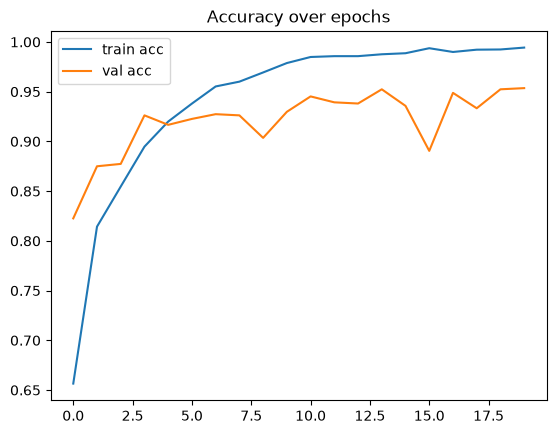

In [6]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy over epochs")
plt.show()

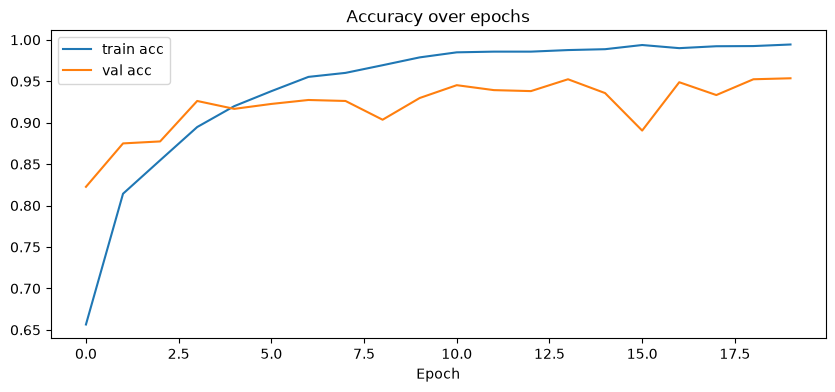

In [7]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9920 - loss: 0.0243 - precision: 0.9920 - recall: 0.9918 - val_accuracy: 0.9369 - val_loss: 0.3086 - val_precision: 0.9369 - val_recall: 0.9369
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.9910 - loss: 0.0253 - precision: 0.9910 - recall: 0.9910 - val_accuracy: 0.9524 - val_loss: 0.2499 - val_precision: 0.9524 - val_recall: 0.9524
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - accuracy: 0.9868 - loss: 0.0406 - precision: 0.9868 - recall: 0.9866 - val_accuracy: 0.9512 - val_loss: 0.2231 - val_precision: 0.9511 - val_recall: 0.9488
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9945 - loss: 0.0173 - precision: 0.9945 - recall: 0.9945 - val_accuracy: 0.9548 - val_loss: 0.2391 - val_precision: 0.9558 - val_recall: 0.9536
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.9960 - loss: 0.0135 - precision: 0.9960 - recall: 0.9960 - val_accuracy: 0.9488 - val

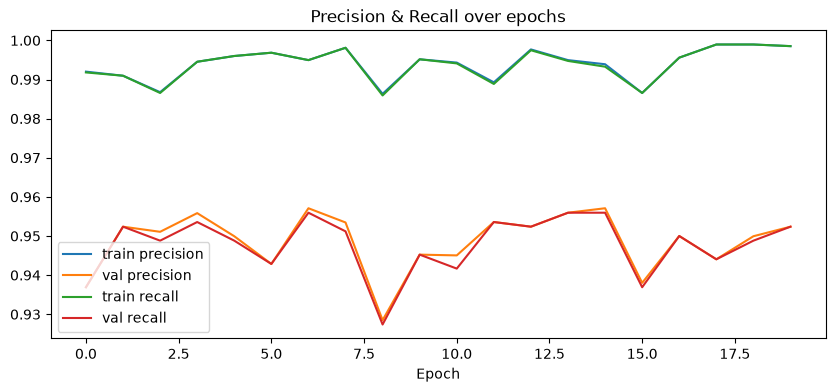

In [11]:
plt.figure(figsize=(10,4))
plt.plot(history.history['precision'], label='train precision')
plt.plot(history.history['val_precision'], label='val precision')
plt.plot(history.history['recall'], label='train recall')
plt.plot(history.history['val_recall'], label='val recall')
plt.title("Precision & Recall over epochs")
plt.xlabel("Epoch")
plt.legend()
plt.show()

              precision    recall  f1-score   support

      glioma       0.94      0.76      0.84       400
  meningioma       0.86      0.93      0.89       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.95      0.96      0.96       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



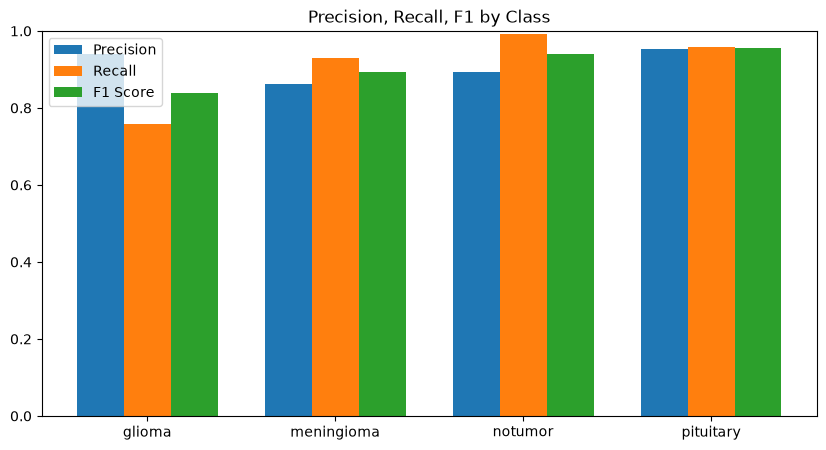

In [12]:
import numpy as np
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix
import seaborn as sns

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Text report
print(classification_report(y_true, y_pred, target_names=class_names))

# Per-class precision, recall, F1 as a bar chart
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')
plt.xticks(x, class_names)
plt.ylim(0, 1)
plt.title("Precision, Recall, F1 by Class")
plt.legend()
plt.show()

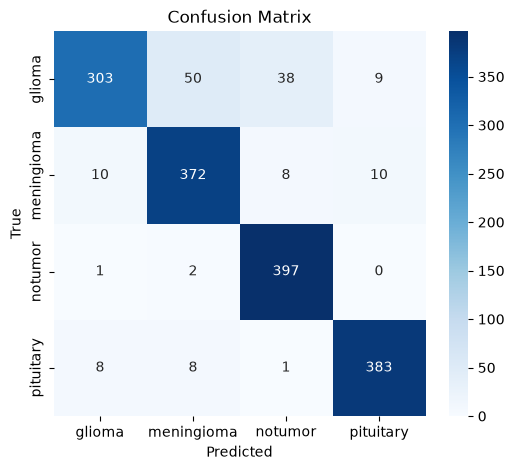

In [13]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

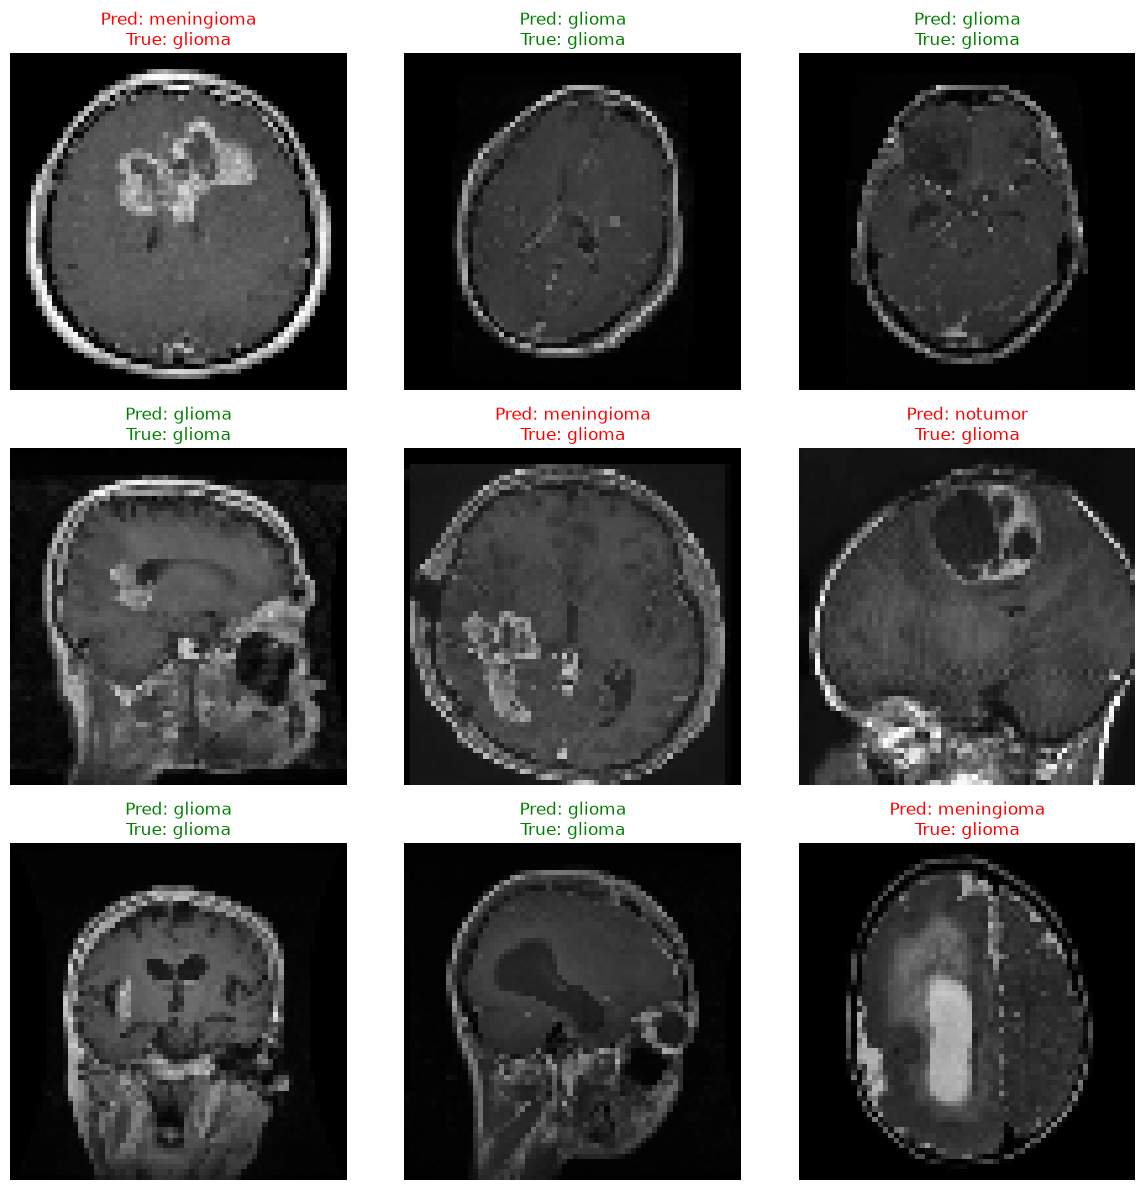

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Grab one batch of test images
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    plt.figure(figsize=(12, 12))
    for i in range(min(9, len(images))):  # show up to 9 images
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())  # already rescaled to [0,1] earlier
        pred_label = class_names[pred_classes[i]]
        true_label = class_names[true_classes[i]]
        color = "green" if pred_classes[i] == true_classes[i] else "red"
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    break